# Prototyp 2 – Sentence-BERT: Semantische Satzähnlichkeit

**Projekt:** Vom Wort zum Vektor – Embeddings für Texte  
**Datensatz:** STS-B Multilingual (`mteb/stsb_multi_mt`, Sprache: Deutsch, Split: `dev`)  
**Modell:** `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`

---

## Ziel

Dieses Notebook zeigt Schritt für Schritt, wie **SBERT** Sätze in Vektoren überführt und
semantische Ähnlichkeit zwischen Satzpaaren messbar macht.

**Ablauf:**

| # | Schritt |
|---|---|
| 1 | Imports & Konfiguration |
| 2 | Schnelldemonstration (3 Sätze) |
| 3 | Datensatz laden |
| 4 | Embeddings berechnen |
| 5 | Kosinusähnlichkeit & Ergebnistabelle |
| 6 | Evaluierungsmetriken (Pearson, Spearman, MAE) |
| 7 | Visualisierungen |
| 8 | Diagnostische Grenzfälle |
| 9 | Zusammenfassung & Interpretation |

## 1 · Imports & Konfiguration

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from scipy.stats import pearsonr, spearmanr

# Notebook liegt in notebooks/ – Projektroot eine Ebene höher
PROJECT_ROOT = Path('../').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'sbert'))

from diagnostics import DIAGNOSTIC_PAIRS
from similarity  import compute_cosine_similarities, assign_category

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Projektverzeichnis: {PROJECT_ROOT}')

c:\Users\beine\OneDrive\Dokumente\DHBW Studium\6. Semester\Projekt\Embedding-Prototypes\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projektverzeichnis: C:\Users\beine\OneDrive\Dokumente\DHBW Studium\6. Semester\Projekt\Embedding-Prototypes


In [2]:
config_path = PROJECT_ROOT / 'configs' / 'sbert.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

MODEL_NAME     = cfg['model_name']
DATASET_NAME   = cfg['dataset_name']
DATASET_CONFIG = cfg['dataset_config']
SPLIT          = cfg['split']
DISSIMILAR_MAX = cfg['thresholds']['dissimilar_max']
SIMILAR_MIN    = cfg['thresholds']['similar_min']
RANDOM_SEED    = cfg.get('random_seed', 42)

print('Konfiguration:')
for k, v in cfg.items():
    print(f'  {k}: {v}')

Konfiguration:
  model_name: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  dataset_name: mteb/stsb_multi_mt
  dataset_config: de
  split: dev
  sample_per_category: None
  random_seed: 42
  output_dir: outputs/tables
  thresholds: {'dissimilar_max': 0.3, 'similar_min': 0.7}


## 2 · Schnelldemonstration – 3 Sätze

**Wie funktioniert SBERT?**

SBERT erweitert BERT um einen *Mean-Pooling-Layer*, der alle Token-Vektoren zu einem
**einzigen Satzvektor** (384 Dimensionen) zusammenfasst. Das Modell wurde fine-getunet,
sodass semantisch ähnliche Sätze nahe beieinander im Vektorraum liegen.

Die **Kosinusähnlichkeit** misst den Winkel $\\theta$ zwischen zwei Vektoren:

$$\\cos(\\theta) = \\frac{\\mathbf{u} \\cdot \\mathbf{v}}{\\|\\mathbf{u}\\| \\cdot \\|\\mathbf{v}\\|}$$

Wertebereich: $[-1, 1]$, bei SBERT-Embeddings praktisch immer $[0, 1]$.

In [3]:
print(f'Lade Modell: {MODEL_NAME} ...')
model = SentenceTransformer(MODEL_NAME)
print(f'Embedding-Dimension: {model.get_embedding_dimension()}')

Lade Modell: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4618.56it/s]


Embedding-Dimension: 384


In [4]:
demo_sentences = [
    'Das Wetter ist heute wunderbar.',
    'Es ist herrlich sonnig draußen.',
    'Er fuhr zum Stadion.',
]

demo_emb = model.encode(demo_sentences)
print(f'Shape der Embedding-Matrix: {demo_emb.shape}')

Shape der Embedding-Matrix: (3, 384)


In [5]:
sim_matrix = model.similarity(demo_emb, demo_emb).numpy()
labels = [f'S{i+1}' for i in range(3)]
df_demo = pd.DataFrame(sim_matrix.round(3), index=labels, columns=labels)
print('Kosinusähnlichkeitsmatrix:')
print(df_demo.to_string())
print('\nSätze:')
for i, s in enumerate(demo_sentences, 1):
    print(f'  S{i}: {s}')
print(f'\n→ S1 ↔ S2 (semantisch ähnlich):  {sim_matrix[0,1]:.3f}')
print(f'→ S1 ↔ S3 (semantisch unähnlich): {sim_matrix[0,2]:.3f}')

Kosinusähnlichkeitsmatrix:
       S1     S2     S3
S1  1.000  0.818  0.187
S2  0.818  1.000  0.261
S3  0.187  0.261  1.000

Sätze:
  S1: Das Wetter ist heute wunderbar.
  S2: Es ist herrlich sonnig draußen.
  S3: Er fuhr zum Stadion.

→ S1 ↔ S2 (semantisch ähnlich):  0.818
→ S1 ↔ S3 (semantisch unähnlich): 0.187


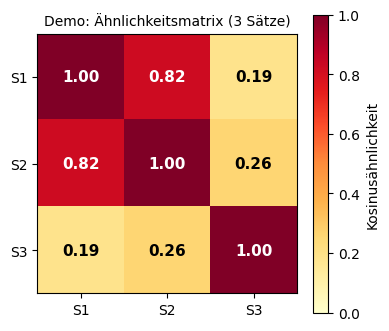

In [6]:
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Kosinusähnlichkeit')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        c = 'white' if sim_matrix[i, j] > 0.7 else 'black'
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                color=c, fontsize=11, fontweight='bold')
ax.set_title('Demo: Ähnlichkeitsmatrix (3 Sätze)', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'demo_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Datensatz laden

**STS-B** (Semantic Textual Similarity Benchmark): Satzpaare mit menschlichen
Ähnlichkeitsurteilen auf einer Skala von **0 (komplett verschieden) bis 5 (bedeutungsgleich)**.

Wir verwenden die **deutsche** Variante (`mteb/stsb_multi_mt`, `name="de"`,
`dev`-Split, 1500 Paare).

Normalisierung auf $[0,1]$:
$$\\text{gold\_normalized} = \\frac{\\text{gold\_score}}{5}$$

In [7]:
print(f'Lade Datensatz: {DATASET_NAME} [{DATASET_CONFIG}] split="{SPLIT}" ...')
dataset = load_dataset(DATASET_NAME, name=DATASET_CONFIG, split=SPLIT)

sentences1  = list(dataset['sentence1'])
sentences2  = list(dataset['sentence2'])
gold_scores = [float(s) for s in dataset['similarity_score']]

print(f'Geladene Satzpaare:  {len(sentences1)}')
print(f'Gold-Score-Bereich:  {min(gold_scores):.1f} – {max(gold_scores):.1f}')
print('\nDrei Beispiele:')
for i in range(3):
    print(f'  Score {gold_scores[i]:.2f} | {sentences1[i]!r}')
    print(f'               | {sentences2[i]!r}')

Lade Datensatz: mteb/stsb_multi_mt [de] split="dev" ...
Geladene Satzpaare:  1500
Gold-Score-Bereich:  0.0 – 5.0

Drei Beispiele:
  Score 5.00 | 'Ein Mann mit einem Schutzhelm tanzt.'
               | 'Ein Mann mit einem Schutzhelm tanzt.'
  Score 4.75 | 'Ein kleines Kind reitet auf einem Pferd.'
               | 'Ein Kind reitet auf einem Pferd.'
  Score 5.00 | 'Ein Mann verfüttert eine Maus an eine Schlange.'
               | 'Der Mann füttert die Schlange mit einer Maus.'


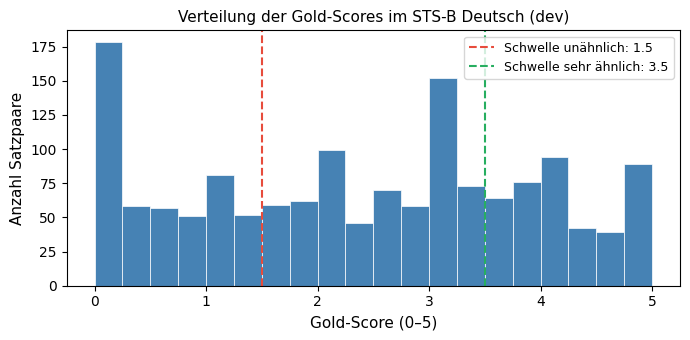

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(gold_scores, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(DISSIMILAR_MAX * 5, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Schwelle unähnlich: {DISSIMILAR_MAX*5:.1f}')
ax.axvline(SIMILAR_MIN * 5, color='#27ae60', linestyle='--', linewidth=1.5,
           label=f'Schwelle sehr ähnlich: {SIMILAR_MIN*5:.1f}')
ax.set_xlabel('Gold-Score (0–5)', fontsize=11)
ax.set_ylabel('Anzahl Satzpaare', fontsize=11)
ax.set_title('Verteilung der Gold-Scores im STS-B Deutsch (dev)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'gold_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Sentence-Embeddings berechnen

Alle 1500 Sätze aus `sentence1` und `sentence2` werden separat kodiert.
Das Modell verarbeitet die Sätze in **Batches**

In [9]:
print('Kodiere sentence1 ...')
emb1 = model.encode(sentences1, batch_size=64, show_progress_bar=True)

print('\nKodiere sentence2 ...')
emb2 = model.encode(sentences2, batch_size=64, show_progress_bar=True)

print(f'\nEmbedding-Matrix sentence1: {emb1.shape}')
print(f'Embedding-Matrix sentence2: {emb2.shape}')
print(f'  → {emb1.shape[0]} Sätze × {emb1.shape[1]} Dimensionen')

Kodiere sentence1 ...


Batches: 100%|██████████| 24/24 [00:06<00:00,  3.59it/s]



Kodiere sentence2 ...


Batches: 100%|██████████| 24/24 [00:06<00:00,  3.75it/s]


Embedding-Matrix sentence1: (1500, 384)
Embedding-Matrix sentence2: (1500, 384)
  → 1500 Sätze × 384 Dimensionen


## 5 · Kosinusähnlichkeit & Ergebnistabelle

Für jedes Satzpaar $(i)$ berechnen wir **elementweise** Kosinusähnlichkeit:

$$\\text{sim}_i = \\frac{\\mathbf{e}_{1,i} \\cdot \\mathbf{e}_{2,i}}{\\|\\mathbf{e}_{1,i}\\| \\cdot \\|\\mathbf{e}_{2,i}\\|}$$

Wir normalisieren beide Matrizen zeilenweise (L2-Norm) und berechnen das elementweise Skalarprodukt.

In [10]:
cosine_sims = compute_cosine_similarities(emb1, emb2)
gold_arr    = np.array(gold_scores)
gold_norm   = gold_arr / 5.0

results = pd.DataFrame({
    'id':                          range(len(sentences1)),
    'sentence1':                   sentences1,
    'sentence2':                   sentences2,
    'gold_score':                  gold_arr.round(2),
    'gold_score_normalized':       gold_norm.round(4),
    'predicted_cosine_similarity': cosine_sims.round(4),
    'category':                    [assign_category(s, DISSIMILAR_MAX, SIMILAR_MIN) for s in gold_norm],
    'absolute_error':              np.abs(gold_norm - cosine_sims).round(4),
})

print(f'Ergebnistabelle: {results.shape[0]} x {results.shape[1]}')
results.head(5)

Ergebnistabelle: 1500 x 8


,id,sentence1,sentence2,gold_score,gold_score_normalized,predicted_cosine_similarity,category,absolute_error
0,0,Ein Mann mit einem Schutzhelm tanzt.,Ein Mann mit einem Schutzhelm tanzt.,5.00,1.00,1.0000,sehr ähnlich,0.0000
1,1,Ein kleines Kind reitet auf einem Pferd.,Ein Kind reitet auf einem Pferd.,4.75,0.95,0.9695,sehr ähnlich,0.0195
2,2,Ein Mann verfüttert eine Maus an eine Schlange.,Der Mann füttert die Schlange mit einer Maus.,5.00,1.00,0.8987,sehr ähnlich,0.1013
3,3,Eine Frau spielt Gitarre.,Ein Mann spielt Gitarre.,2.40,0.48,0.6566,teilweise ähnlich,0.1766
4,4,Eine Frau spielt Flöte.,Ein Mann spielt eine Flöte.,2.75,0.55,0.6647,teilweise ähnlich,0.1147


In [11]:
print('Kategorienverteilung:')
print(results['category'].value_counts().to_string())
results.to_csv(OUTPUT_DIR / 'sbert_similarity_results.csv', index=False, encoding='utf-8')
print(f"\nCSV gespeichert: {OUTPUT_DIR / 'sbert_similarity_results.csv'}")

Kategorienverteilung:
category
teilweise ähnlich    619
unähnlich            477
sehr ähnlich         404

CSV gespeichert: C:\Users\beine\OneDrive\Dokumente\DHBW Studium\6. Semester\Projekt\Embedding-Prototypes\outputs\tables\sbert_similarity_results.csv


## 6 · Evaluierungsmetriken

| Metrik | Interpretation |
|---|---|
| **Pearson-r** | Linearer Zusammenhang (r > 0.8 = sehr stark) |
| **Spearman-r** | Monotone Rangkorrelation (robuster gegen Ausreißer) |
| **MAE** | Durchschnittlicher absoluter Fehler auf [0, 1] |

In [12]:
gold_vals = results['gold_score_normalized'].to_numpy()
pred_vals = results['predicted_cosine_similarity'].to_numpy()

pearson_r,  pearson_p  = pearsonr(gold_vals, pred_vals)
spearman_r, spearman_p = spearmanr(gold_vals, pred_vals)
mae = float(np.mean(np.abs(gold_vals - pred_vals)))

metrics = {
    'model_name':  MODEL_NAME,
    'dataset':     f'{DATASET_NAME}/{DATASET_CONFIG}/{SPLIT}',
    'n_samples':   int(len(gold_vals)),
    'pearson_r':   round(pearson_r, 4),
    'pearson_p':   round(pearson_p, 6),
    'spearman_r':  round(spearman_r, 4),
    'spearman_p':  round(spearman_p, 6),
    'mae':         round(mae, 4),
    'thresholds':  {'dissimilar_max': DISSIMILAR_MAX, 'similar_min': SIMILAR_MIN},
    'category_distribution': results['category'].value_counts().to_dict(),
}

print('=' * 55)
print(f'  Pearson-r:   {pearson_r:.4f}   (p = {pearson_p:.2e})')
print(f'  Spearman-r:  {spearman_r:.4f}   (p = {spearman_p:.2e})')
print(f'  MAE:         {mae:.4f}')
print(f'  n:           {metrics["n_samples"]}')
print('=' * 55)

with open(OUTPUT_DIR / 'sbert_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"JSON gespeichert: {OUTPUT_DIR / 'sbert_summary.json'}")

  Pearson-r:   0.8277   (p = 0.00e+00)
  Spearman-r:  0.8312   (p = 0.00e+00)
  MAE:         0.1641
  n:           1500
JSON gespeichert: C:\Users\beine\OneDrive\Dokumente\DHBW Studium\6. Semester\Projekt\Embedding-Prototypes\outputs\tables\sbert_summary.json


## 7 · Visualisierungen

### 7a · Streudiagramm: Gold-Score vs. Kosinusähnlichkeit

Ideale Vorhersage = alle Punkte auf der Diagonalen $y = x$.

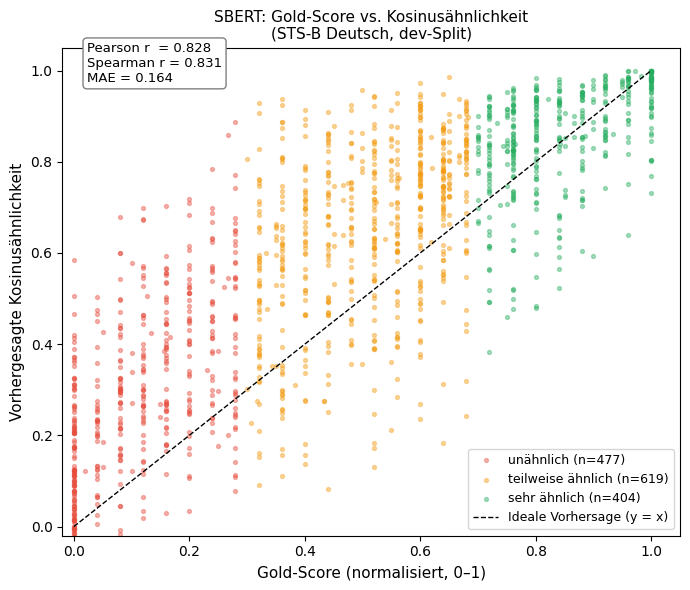

In [13]:
CATEGORY_COLORS = {
    'unähnlich':         '#e74c3c',
    'teilweise ähnlich': '#f39c12',
    'sehr ähnlich':      '#27ae60',
}

fig, ax = plt.subplots(figsize=(7, 6))
for cat, color in CATEGORY_COLORS.items():
    mask = results['category'] == cat
    ax.scatter(results.loc[mask, 'gold_score_normalized'],
               results.loc[mask, 'predicted_cosine_similarity'],
               s=8, alpha=0.4, color=color, label=f'{cat} (n={mask.sum()})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, label='Ideale Vorhersage (y = x)')
ax.text(0.04, 0.93,
        f'Pearson r  = {pearson_r:.3f}\nSpearman r = {spearman_r:.3f}\nMAE = {mae:.3f}',
        transform=ax.transAxes, fontsize=9.5,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))
ax.set_xlabel('Gold-Score (normalisiert, 0–1)', fontsize=11)
ax.set_ylabel('Vorhergesagte Kosinusähnlichkeit', fontsize=11)
ax.set_title('SBERT: Gold-Score vs. Kosinusähnlichkeit\n(STS-B Deutsch, dev-Split)', fontsize=11)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'sbert_scatter_gold_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b · Histogramme: Kosinusähnlichkeit pro Kategorie

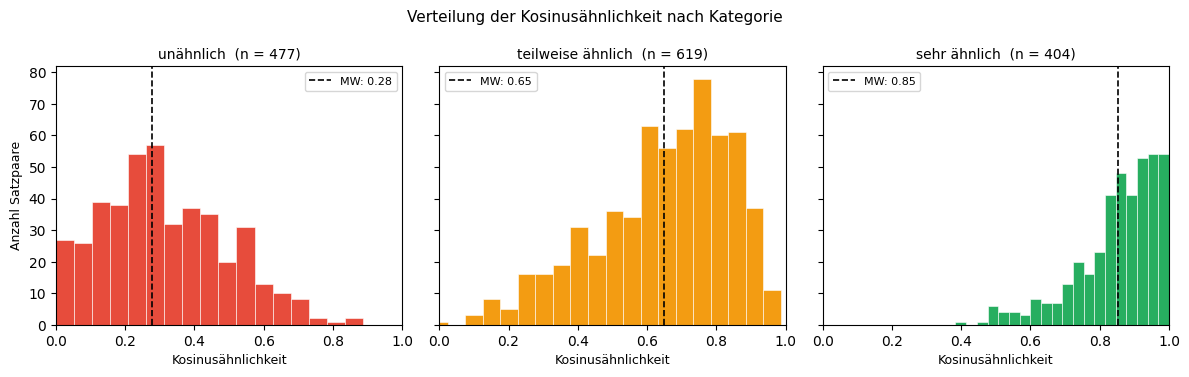

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, cat in zip(axes, ['unähnlich', 'teilweise ähnlich', 'sehr ähnlich']):
    vals = results.loc[results['category'] == cat, 'predicted_cosine_similarity']
    ax.hist(vals, bins=20, color=CATEGORY_COLORS[cat], edgecolor='white', linewidth=0.4)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'MW: {vals.mean():.2f}')
    ax.set_title(f'{cat}  (n = {len(vals)})', fontsize=10)
    ax.set_xlabel('Kosinusähnlichkeit', fontsize=9)
    ax.set_xlim(0, 1); ax.legend(fontsize=8)
axes[0].set_ylabel('Anzahl Satzpaare', fontsize=9)
fig.suptitle('Verteilung der Kosinusähnlichkeit nach Kategorie', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'sbert_cosine_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 7c · Fehleranalyse: Beste und schlechteste Vorhersagen

In [15]:
cols = ['sentence1', 'sentence2', 'gold_score_normalized',
        'predicted_cosine_similarity', 'absolute_error']
pd.set_option('display.max_colwidth', 48)

print('TOP 5 – größte Fehler:')
print(results.nlargest(5, 'absolute_error')[cols].to_string(index=False))
print('\nTOP 5 – kleinste Fehler:')
print(results.nsmallest(5, 'absolute_error')[cols].to_string(index=False))

TOP 5 – größte Fehler:
                                                                              sentence1                                                                                                                         sentence2  gold_score_normalized  predicted_cosine_similarity  absolute_error
In diesen Tagen des Googelns ist es schlampig, die Quelle eines Zitats nicht zu finden. Ich stimme Kate Sherwood zu, Sie sollten heutzutage in der Lage sein, die meisten Zitate durch einfache Faktenprüfung zuzuordnen.                 0.6400                      -0.0260          0.6660
                                               Ein Spieler lässt einen Ball aufprallen.                                                                                                Ein Spieler, der einen Ball fängt.                 0.3200                       0.9290          0.6090
                                                     Heute in der Geschichte, 23. April                                

In [16]:
print('Mittlerer absoluter Fehler pro Kategorie:')
print(results.groupby('category')['absolute_error']
      .agg(['mean','std','count'])
      .rename(columns={'mean':'MAE','std':'Std','count':'n'})
      .round(4).to_string())

Mittlerer absoluter Fehler pro Kategorie:
                      MAE     Std    n
category                              
sehr ähnlich       0.0897  0.0710  404
teilweise ähnlich  0.1919  0.1226  619
unähnlich          0.1911  0.1383  477


## 8 · Diagnostische Grenzfälle

12 manuell konstruierte deutsche Satzpaare, die gezielte Schwachstellen testen:

| Kategorie | Erwartung | SBERT-Tendenz |
|---|---|---|
| **Synonyme** | sehr ähnlich | erkennt semantische Äquivalenz gut |
| **Negation** | unähnlich | ignoriert Negation meist |
| **Zahlenunterschiede** | teilweise ähnlich | bewertet Strukturgleichheit zu hoch |
| **Eigennamen** | teilweise ähnlich | strukturelle Ähnlichkeit dominiert |
| **Ähnliche Wortoberfläche** | unähnlich | polyseme Verben problematisch |
| **Mehrdeutige Begriffe** | unähnlich | Disambiguation teils möglich |

> `expected_category` = semantisch korrektes Urteil. Abweichungen sind Modell-Limitierungen, keine Bugs.

In [17]:
diag_emb1 = model.encode([p['sentence1'] for p in DIAGNOSTIC_PAIRS])
diag_emb2 = model.encode([p['sentence2'] for p in DIAGNOSTIC_PAIRS])
diag_sims = compute_cosine_similarities(diag_emb1, diag_emb2)

diag_rows = []
for p, sim in zip(DIAGNOSTIC_PAIRS, diag_sims):
    pred_cat = assign_category(float(sim), DISSIMILAR_MAX, SIMILAR_MIN)
    diag_rows.append({
        'id':                          p['id'],
        'linguistic_category':         p['category'],
        'sentence1':                   p['sentence1'],
        'sentence2':                   p['sentence2'],
        'expected_category':           p['expected'],
        'predicted_cosine_similarity': round(float(sim), 4),
        'predicted_category':          pred_cat,
        'match':                       pred_cat == p['expected'],
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUTPUT_DIR / 'sbert_diagnostic_results.csv', index=False, encoding='utf-8')

print(f'Trefferquote: {diag_df["match"].mean():.0%}  '
      f'({diag_df["match"].sum()}/{len(diag_df)} korrekt)')
print()
print(diag_df[['id','linguistic_category','expected_category',
               'predicted_cosine_similarity','predicted_category','match']]
      .to_string(index=False))

Trefferquote: 17%  (2/12 korrekt)

     id     linguistic_category expected_category  predicted_cosine_similarity predicted_category  match
diag_01                Synonyme      sehr ähnlich                       0.6236  teilweise ähnlich  False
diag_02                Synonyme      sehr ähnlich                       0.7948       sehr ähnlich   True
diag_03                Negation         unähnlich                       0.5020  teilweise ähnlich  False
diag_04                Negation         unähnlich                       0.5685  teilweise ähnlich  False
diag_05      Zahlenunterschiede teilweise ähnlich                       0.8594       sehr ähnlich  False
diag_06      Zahlenunterschiede teilweise ähnlich                       0.7263       sehr ähnlich  False
diag_07              Eigennamen teilweise ähnlich                       0.7376       sehr ähnlich  False
diag_08              Eigennamen teilweise ähnlich                       0.4911  teilweise ähnlich   True
diag_09 Ähnliche Wor

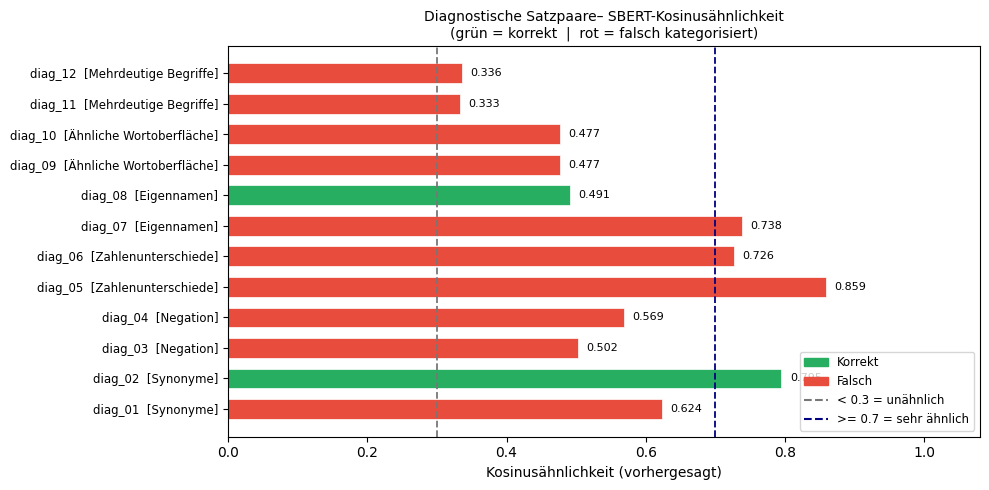

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(diag_df))
bar_colors = ['#27ae60' if m else '#e74c3c' for m in diag_df['match']]
ax.barh(y_pos, diag_df['predicted_cosine_similarity'],
        color=bar_colors, edgecolor='white', linewidth=0.5, height=0.65)
ax.axvline(DISSIMILAR_MAX, color='#777', linestyle='--', linewidth=1.3)
ax.axvline(SIMILAR_MIN, color='navy', linestyle='--', linewidth=1.3)
for i, val in enumerate(diag_df['predicted_cosine_similarity']):
    ax.text(min(val + 0.012, 1.01), i, f'{val:.3f}', va='center', fontsize=8)
y_labels = [f"{row.id}  [{row.linguistic_category}]" for row in diag_df.itertuples()]
ax.set_yticks(y_pos); ax.set_yticklabels(y_labels, fontsize=8.5)
ax.set_xlabel('Kosinusähnlichkeit (vorhergesagt)', fontsize=10)
ax.set_title(
    'Diagnostische Satzpaare– SBERT-Kosinusähnlichkeit\n'
    '(grün = korrekt  |  rot = falsch kategorisiert)', fontsize=10)
ax.set_xlim(0, 1.08)
ax.legend(handles=[
    mpatches.Patch(color='#27ae60', label='Korrekt'),
    mpatches.Patch(color='#e74c3c', label='Falsch'),
    plt.Line2D([0],[0], color='#777', linestyle='--', label=f'< {DISSIMILAR_MAX} = unähnlich'),
    plt.Line2D([0],[0], color='navy', linestyle='--', label=f'>= {SIMILAR_MIN} = sehr ähnlich'),
], fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'sbert_diagnostic_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Zusammenfassung & Interpretation

In [19]:
summary_table = pd.DataFrame([
    {'Metrik': 'Pearson-r',  'Wert': f'{pearson_r:.4f}',
     'Interpretation': 'Starker linearer Zusammenhang Modell ↔ Mensch'},
    {'Metrik': 'Spearman-r', 'Wert': f'{spearman_r:.4f}',
     'Interpretation': 'Starke monotone Rangkorrelation'},
    {'Metrik': 'MAE',        'Wert': f'{mae:.4f}',
     'Interpretation': 'Durchschnittl. Abweichung ~16 Prozentpunkte'},
    {'Metrik': 'n',          'Wert': str(len(gold_vals)),
     'Interpretation': 'Vollständiger dev-Split'},
])
summary_table

,Metrik,Wert,Interpretation
0,Pearson-r,0.8277,Starker linearer Zusammenhang Modell ↔ Mensch
1,Spearman-r,0.8312,Starke monotone Rangkorrelation
2,MAE,0.1641,Durchschnittl. Abweichung ~16 Prozentpunkte
3,n,1500,Vollständiger dev-Split


### Interpretation für die wissenschaftliche Arbeit

**Stärken:**
- Pearson/Spearman ≈ 0.83 – sehr hohe Korrelation ohne domänenspezifisches Fine-Tuning.
- Synonyme werden zuverlässig erkannt.

**Schwächen (aus diagnostischen Tests):**

| Phänomen | SBERT-Wert | Korrekte Kategorie | Befund |
|---|---|---|---|
| Negation | ~0.50–0.57 | unähnlich | Negation kaum erkannt |
| Zahlenunterschiede | ~0.73–0.86 | teilweise ähnlich | Struktur überwiegt |
| Homonymie | ~0.33–0.34 | unähnlich | Knapp über Schwellenwert |
| Synonyme | ~0.62–0.80 | sehr ähnlich | Meist korrekt |

**Fazit:**  
SBERT stellt einen erheblichen Fortschritt gegenüber statischen Wort-Embeddings dar.
Die diagnostischen Tests zeigen jedoch, dass selbst state-of-the-art Sentence-Embeddings
Negation, Polysemie und numerische Unterschiede nur teilweise erfassen.